In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

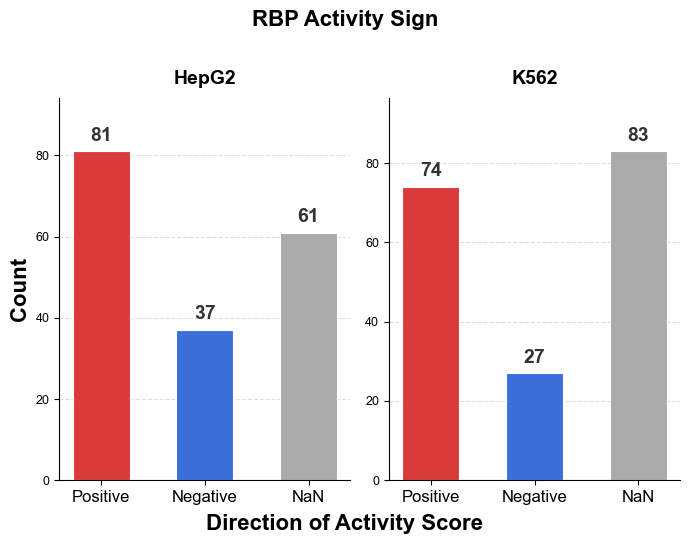

Saved → rbp_barplots.png


In [8]:
# ── Load data ──────────────────────────────────────────────────────────────────
df = pd.read_csv("heatmap.csv")
value_cols = ["1", "2", "3", "4", "5", "6"]

# ── Plot ───────────────────────────────────────────────────────────────────────
plt.style.use("../../paper.mplstyle")

cell_lines = sorted(df["Cell Line"].unique(), key=lambda x: (x != "HepG2", x != "K562"))
categories = ["positive", "negative", "nan"]
colors = {"positive": "#D93B3B", "negative": "#3B6FD9", "nan": "#AAAAAA"}
x_labels = {"positive": "Positive", "negative": "Negative", "nan": "NaN"}

n_lines = len(cell_lines)
fig, axes = plt.subplots(1, n_lines, figsize=(3.5 * n_lines, 5), sharey=False)
if n_lines == 1:
    axes = [axes]

for ax, cell_line in zip(axes, cell_lines):
    subset = df[df["Cell Line"] == cell_line][value_cols]
    counts = {
        "positive": (subset > 0).sum().sum(),
        "negative": (subset < 0).sum().sum(),
        "nan":      subset.isna().sum().sum(),
    }
    bars = ax.bar(
        [x_labels[c] for c in categories],
        [counts[c] for c in categories],
        color=[colors[c] for c in categories],
        edgecolor="white",
        linewidth=0.8,
        width=0.55,
    )
    max_count = max(counts.values()) if max(counts.values()) > 0 else 1
    for bar, cat in zip(bars, categories):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + max_count * 0.02,
            str(int(height)),
            ha="center",
            va="bottom",
            fontsize=14,
            fontweight="bold",
            color="#333333",
        )
    ax.set_title(cell_line, fontsize=14, fontweight="bold", pad=10)
    ax.set_ylabel("Count" if ax == axes[0] else "", fontsize=16, fontweight="bold")
    ax.set_ylim(0, max_count * 1.15 + 1)
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

fig.text(0.5, -0.02, "Direction of Activity Score", fontweight="bold", ha="center", fontsize=16)
fig.suptitle("RBP Activity Sign", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("rbp_barplots.pdf", bbox_inches='tight')
plt.show()
print("Saved → rbp_barplots.pdf")